# POMDP Oil Futures Trading

This notebook implements a POMDP (Partially Observable Markov Decision Process) approach to trading WTI crude oil futures based on weather data.

## Key Components
- **Hidden States**: Market regimes (bull/bear/volatile/calm) learned from historical returns
- **Observations**: Weather features (temperature, precipitation, hurricanes)
- **Actions**: SHORT (-1), FLAT (0), LONG (+1)
- **Belief State**: Probability distribution over hidden states, updated via Bayesian inference

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pomdp_model import WTIPOMDPModel

## 1. Load Data with Hurricane Features

In [2]:
# Load the merged dataset (includes weather + hurricane data)
df = pd.read_csv('wti_1_data_with_hurricanes.csv')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns:")
print(df.columns.tolist())

Dataset shape: (9586, 62)
Date range: 1986-01-02 to 2024-04-05

Columns:
['Date', 'spot_price', 'CL1', 'ret_CL1', 'alaska_temp', 'alaska_precip', 'bakken_temp', 'bakken_precip', 'western_canada_temp', 'western_canada_precip', 'midwest_corridor_temp', 'midwest_corridor_precip', 'ok_hub_temp', 'ok_hub_precip', 'permian_temp', 'permian_precip', 'rockies_temp', 'rockies_precip', 'texas_gulf_temp', 'texas_gulf_precip', 'bakken_temp_producing', 'bakken_precip_producing', 'canada_temp_producing', 'canada_precip_producing', 'eagle_temp_producing', 'eagle_precip_producing', 'central_kansas_temp_producing', 'central_kansas_precip_producing', 'n_alaska_temp_producing', 'n_alaska_precip_producing', 'nc_ok_temp_producing', 'nc_ok_precip_producing', 'ne_ok_temp_producing', 'ne_ok_precip_producing', 'nw_ok_temp_producing', 'nw_ok_precip_producing', 'permian_temp_producing', 'permian_precip_producing', 's_alaska_temp_producing', 's_alaska_precip_producing', 'saskatchewan_temp_producing', 'saskatchewan

In [3]:
# Define features and target
feature_cols = [c for c in df.columns if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']]
return_col = 'ret_CL1'

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature types:")
print(f"  - Pipeline weather (temp + precip): 16 features")
print(f"  - Producing region weather: 26 features")
print(f"  - Hurricane data: 16 features")

Number of features: 58

Feature types:
  - Pipeline weather (temp + precip): 16 features
  - Producing region weather: 26 features
  - Hurricane data: 16 features


In [4]:
# Check for NaN values
nan_counts = df.isna().sum()
print(f"NaN values in ret_CL1: {nan_counts['ret_CL1']}")
print("(These will be automatically dropped during model fitting)")

NaN values in ret_CL1: 3
(These will be automatically dropped during model fitting)


## 2. Train/Test Split

In [5]:
# Time-based split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print(f"Training data: {len(train_df)} samples ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Test data: {len(test_df)} samples ({test_df['Date'].min()} to {test_df['Date'].max()})")

Training data: 7668 samples (1986-01-02 to 2016-07-29)
Test data: 1918 samples (2016-08-01 to 2024-04-05)


## 3. POMDP Model

### How it works:
1. **Learn Hidden States**: Cluster historical returns into market regimes using K-means
2. **Learn Transition Model**: P(s' | s) - how market regimes transition
3. **Learn Observation Model**: P(o | s) - how weather relates to market regimes
4. **Belief Updates**: Use Bayesian inference to update belief state after each observation
5. **Q-Learning**: Learn value function over belief states

In [6]:
# Create and fit POMDP model
pomdp = WTIPOMDPModel(
    n_hidden_states=4,   # Number of market regimes
    n_obs_clusters=8,    # Number of weather observation clusters
    gamma=0.95           # Discount factor
)

pomdp.fit(train_df, feature_cols, return_col)

Learning POMDP from 7668 samples...
  - 4 hidden market states
  - 8 observation clusters
POMDP model learned!


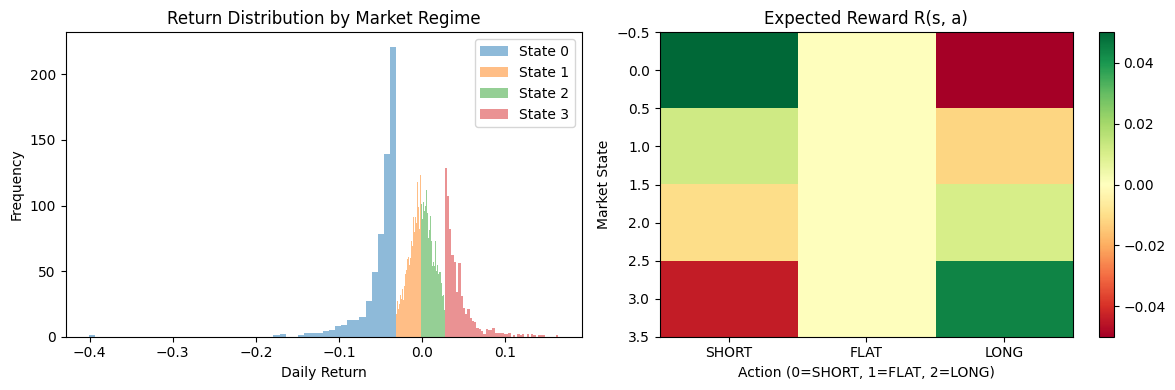

In [7]:
# Visualize the learned market regimes
train_returns = train_df.dropna(subset=[return_col])[return_col].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Return distribution by state
for s in range(pomdp.n_states):
    state_returns = train_returns[pomdp.states == s]
    axes[0].hist(state_returns, bins=50, alpha=0.5, label=f'State {s}')

axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Return Distribution by Market Regime')
axes[0].legend()

# Reward matrix
im = axes[1].imshow(pomdp.R, cmap='RdYlGn', aspect='auto')
axes[1].set_xlabel('Action (0=SHORT, 1=FLAT, 2=LONG)')
axes[1].set_ylabel('Market State')
axes[1].set_title('Expected Reward R(s, a)')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['SHORT', 'FLAT', 'LONG'])
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

## 4. Train Q-Learning over Belief States

In [11]:
# Train Q-learning (belief-based)
training_rewards = pomdp.train_qlearning(
    train_df, 
    feature_cols, 
    return_col,
    n_episodes=2000,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.1
)

Episode 10/2000, Avg Reward: -3.8871, Epsilon: 0.996
Episode 20/2000, Avg Reward: -4.1207, Epsilon: 0.991
Episode 30/2000, Avg Reward: -4.1946, Epsilon: 0.987
Episode 40/2000, Avg Reward: -3.8205, Epsilon: 0.982
Episode 50/2000, Avg Reward: -3.3062, Epsilon: 0.978
Episode 60/2000, Avg Reward: -3.1696, Epsilon: 0.973
Episode 70/2000, Avg Reward: -3.4472, Epsilon: 0.969
Episode 80/2000, Avg Reward: -3.6211, Epsilon: 0.964
Episode 90/2000, Avg Reward: -4.1309, Epsilon: 0.960
Episode 100/2000, Avg Reward: -3.4188, Epsilon: 0.955
Episode 110/2000, Avg Reward: -3.0202, Epsilon: 0.951
Episode 120/2000, Avg Reward: -4.4130, Epsilon: 0.946
Episode 130/2000, Avg Reward: -3.2313, Epsilon: 0.942
Episode 140/2000, Avg Reward: -3.6571, Epsilon: 0.937
Episode 150/2000, Avg Reward: -3.5294, Epsilon: 0.933
Episode 160/2000, Avg Reward: -3.3961, Epsilon: 0.928
Episode 170/2000, Avg Reward: -4.2424, Epsilon: 0.924
Episode 180/2000, Avg Reward: -3.6850, Epsilon: 0.919
Episode 190/2000, Avg Reward: -2.9666

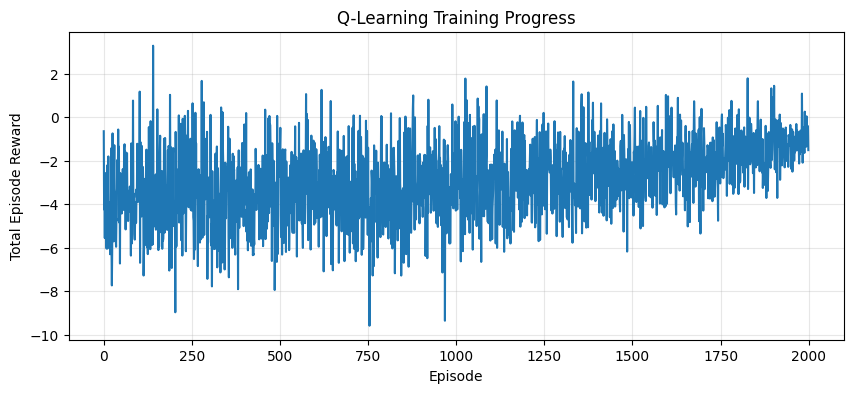

Final 10-episode average reward: -0.8392


In [12]:
# Plot training progress
plt.figure(figsize=(10, 4))
plt.plot(training_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Episode Reward')
plt.title('Q-Learning Training Progress')
plt.grid(True, alpha=0.3)
plt.show()

# Rolling average
window = 10
rolling_avg = pd.Series(training_rewards).rolling(window).mean()
print(f"Final {window}-episode average reward: {rolling_avg.iloc[-1]:.4f}")

## 5. Evaluate on Test Set

In [ ]:
# Evaluate POMDP policy
results = pomdp.evaluate(test_df, feature_cols, return_col, use_qlearning=True)

print("=== POMDP Policy Results ===")
print(f"Total Reward: {results['total_reward']:.4f}")
print(f"Mean Daily Reward: {results['mean_reward']:.6f}")
print(f"Sharpe Ratio (annualized): {results['sharpe']:.4f}")

In [ ]:
# Compare to baselines
test_returns = test_df.dropna(subset=[return_col])[return_col].values[:-1]

# Buy and Hold
buy_hold_reward = test_returns.sum()
buy_hold_sharpe = test_returns.mean() / (test_returns.std() + 1e-8) * np.sqrt(252)

# Sell and Hold (short)
sell_hold_reward = -test_returns.sum()

# Random
np.random.seed(42)
random_positions = np.random.choice([-1, 0, 1], size=len(test_returns))
random_reward = (random_positions * test_returns).sum()

print("\n=== Baseline Comparisons ===")
print(f"Buy & Hold:  Total={buy_hold_reward:.4f}, Sharpe={buy_hold_sharpe:.4f}")
print(f"Sell & Hold: Total={sell_hold_reward:.4f}")
print(f"Random:      Total={random_reward:.4f}")
print(f"POMDP:       Total={results['total_reward']:.4f}, Sharpe={results['sharpe']:.4f}")

In [ ]:
# Plot cumulative returns
pomdp_cumulative = np.cumsum(results['rewards'])
buyhold_cumulative = np.cumsum(test_returns)

plt.figure(figsize=(12, 5))
plt.plot(pomdp_cumulative, label='POMDP Strategy', linewidth=2)
plt.plot(buyhold_cumulative, label='Buy & Hold', linewidth=2, alpha=0.7)
plt.xlabel('Trading Day')
plt.ylabel('Cumulative Return')
plt.title('POMDP Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Position distribution
positions = np.array(results['positions'])
position_counts = pd.Series(positions).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(['SHORT (-1)', 'FLAT (0)', 'LONG (+1)'], 
        [position_counts.get(-1, 0), position_counts.get(0, 0), position_counts.get(1, 0)])
plt.ylabel('Number of Days')
plt.title('Position Distribution')
plt.show()

print(f"Position breakdown:")
print(f"  SHORT: {position_counts.get(-1, 0)} days ({100*position_counts.get(-1, 0)/len(positions):.1f}%)")
print(f"  FLAT:  {position_counts.get(0, 0)} days ({100*position_counts.get(0, 0)/len(positions):.1f}%)")
print(f"  LONG:  {position_counts.get(1, 0)} days ({100*position_counts.get(1, 0)/len(positions):.1f}%)")

## 6. Hyperparameter Tuning

In [ ]:
# Try different numbers of hidden states
results_by_states = {}

for n_states in [2, 3, 4, 5, 6]:
    print(f"\nTrying n_hidden_states={n_states}...")
    model = WTIPOMDPModel(n_hidden_states=n_states, n_obs_clusters=8)
    model.fit(train_df, feature_cols, return_col)
    model.train_qlearning(train_df, feature_cols, return_col, n_episodes=50)
    result = model.evaluate(test_df, feature_cols, return_col)
    results_by_states[n_states] = result['total_reward']
    print(f"  Total Reward: {result['total_reward']:.4f}")

best_n_states = max(results_by_states, key=results_by_states.get)
print(f"\nBest n_hidden_states: {best_n_states} (reward: {results_by_states[best_n_states]:.4f})")

## 7. Using the Gym Environment

For DQN or other deep RL methods, use the WTIEnv gym environment:

In [ ]:
from wti_env import WTIEnv

# Create environment
env = WTIEnv(
    df=df,
    feature_cols=feature_cols,
    return_col=return_col,
    window=20,
    cost=0.0005,
    normalize=True  # Normalizes features for better RL training
)

print(f"Observation space: {env.observation_space.shape}")
print(f"Action space: {env.action_space.n}")

In [ ]:
# Test a random policy
obs, info = env.reset()
total_reward = 0
n_steps = 0

terminated = truncated = False
while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    n_steps += 1

print(f"Random policy: {n_steps} steps, total reward = {total_reward:.4f}")

## Summary

This notebook demonstrates:
1. **Data preparation**: Merged weather + hurricane data, handled NaN values
2. **POMDP formulation**: Hidden market states, weather observations, trading actions
3. **Belief-based Q-learning**: Learning a policy over belief states
4. **Evaluation**: Comparison with baselines (buy & hold, random)

### Next Steps
- Try more sophisticated belief representations
- Use deep RL (DQN, PPO) with the gymnasium environment
- Add more features (volatility index OVX, technical indicators)
- Explore different reward functions (risk-adjusted returns)

In [29]:
## Adding OVX to POMDP

df = pd.read_csv("/Users/ethanhersch/Documents/Documents/Stanford/CS238/FinalProject/CS238_Project/src/pomdp_data/wti_4_data_with_hurricanes.csv")
ovx = pd.read_csv("/Users/ethanhersch/Documents/Documents/Stanford/CS238/FinalProject/CS238_Project/data/ovx_data_chronological.csv")
df = df.merge(ovx, on="Date", how="left")
df['OVX'] = df['OVX'].ffill()  # forward-fill missing values
df_merged = df[df['Date'] >= '2007-05-11']
df_merged.to_csv("wti_4_weather_hurricanes_ovx_since_2007.csv", index=False)
print("Saved as wti_4_weather_hurricanes_ovx_since_2007.csv")

Saved as wti_4_weather_hurricanes_ovx_since_2007.csv


In [26]:
# Load new dataset
df = pd.read_csv("ovx_data/wti_weather_hurricanes_ovx_since_2007.csv")

print("Dataset shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Define features (OVX included automatically)
feature_cols = [
    c for c in df.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("Number of features:", len(feature_cols))

# Split into train-test (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

print(f"Training samples: {len(train_df)}")
print(f"Testing samples:  {len(test_df)}")

# Create model
pomdp = WTIPOMDPModel(
    n_hidden_states=4,
    n_obs_clusters=8,
    gamma=0.95
)

# Fit model
pomdp.fit(train_df, feature_cols, return_col)

# Train Q-learning
training_rewards = pomdp.train_qlearning(
    train_df,
    feature_cols,
    return_col,
    n_episodes=500,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.1
)

print("Final training reward:", np.mean(training_rewards[-10:]))

# Evaluate on test set
results = pomdp.evaluate(test_df, feature_cols, return_col)
print("\n=== Test Results ===")
print("Total Reward:", results['total_reward'])
print("Mean Reward:", results['mean_reward'])
print("Sharpe:", results['sharpe'])


Dataset shape: (4239, 63)
Date range: 2007-05-11 to 2024-04-05
Number of features: 59
Training samples: 3391
Testing samples:  848
Learning POMDP from 3389 samples...
  - 4 hidden market states
  - 8 observation clusters
POMDP model learned!
Episode 10/500, Avg Reward: -1.5520, Epsilon: 0.984
Episode 20/500, Avg Reward: -1.0901, Epsilon: 0.966
Episode 30/500, Avg Reward: -1.4959, Epsilon: 0.948
Episode 40/500, Avg Reward: -1.7489, Epsilon: 0.930
Episode 50/500, Avg Reward: -1.3349, Epsilon: 0.912
Episode 60/500, Avg Reward: -1.2426, Epsilon: 0.894
Episode 70/500, Avg Reward: -0.5367, Epsilon: 0.876
Episode 80/500, Avg Reward: -1.4821, Epsilon: 0.858
Episode 90/500, Avg Reward: -1.2788, Epsilon: 0.840
Episode 100/500, Avg Reward: -1.9150, Epsilon: 0.822
Episode 110/500, Avg Reward: -1.9258, Epsilon: 0.804
Episode 120/500, Avg Reward: -0.9698, Epsilon: 0.786
Episode 130/500, Avg Reward: -1.7741, Epsilon: 0.768
Episode 140/500, Avg Reward: -1.6212, Epsilon: 0.750
Episode 150/500, Avg Rewa

In [31]:
# Load new dataset
df = pd.read_csv("ovx_data/wti_2_weather_hurricanes_ovx_since_2007.csv")

print("Dataset shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Define features (OVX included automatically)
feature_cols = [
    c for c in df.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("Number of features:", len(feature_cols))

# Split into train-test (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

print(f"Training samples: {len(train_df)}")
print(f"Testing samples:  {len(test_df)}")

# Create model
pomdp = WTIPOMDPModel(
    n_hidden_states=4,
    n_obs_clusters=8,
    gamma=0.95
)

# Fit model
pomdp.fit(train_df, feature_cols, return_col)

# Train Q-learning
training_rewards = pomdp.train_qlearning(
    train_df,
    feature_cols,
    return_col,
    n_episodes=500,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.1
)

print("Final training reward:", np.mean(training_rewards[-10:]))

# Evaluate on test set
results = pomdp.evaluate(test_df, feature_cols, return_col)
print("\n=== Test Results ===")
print("Total Reward:", results['total_reward'])
print("Mean Reward:", results['mean_reward'])
print("Sharpe:", results['sharpe'])


Dataset shape: (4239, 63)
Date range: 2007-05-11 to 2024-04-05
Number of features: 59
Training samples: 3391
Testing samples:  848
Learning POMDP from 3391 samples...
  - 4 hidden market states
  - 8 observation clusters
POMDP model learned!
Episode 10/500, Avg Reward: -2.0376, Epsilon: 0.984
Episode 20/500, Avg Reward: -2.1698, Epsilon: 0.966
Episode 30/500, Avg Reward: -1.1030, Epsilon: 0.948
Episode 40/500, Avg Reward: -2.0626, Epsilon: 0.930
Episode 50/500, Avg Reward: -1.8361, Epsilon: 0.912
Episode 60/500, Avg Reward: -0.9750, Epsilon: 0.894
Episode 70/500, Avg Reward: -1.9598, Epsilon: 0.876
Episode 80/500, Avg Reward: -1.3602, Epsilon: 0.858
Episode 90/500, Avg Reward: -1.9551, Epsilon: 0.840
Episode 100/500, Avg Reward: -2.4155, Epsilon: 0.822
Episode 110/500, Avg Reward: -1.2855, Epsilon: 0.804
Episode 120/500, Avg Reward: -0.6899, Epsilon: 0.786
Episode 130/500, Avg Reward: -0.9093, Epsilon: 0.768
Episode 140/500, Avg Reward: -1.3654, Epsilon: 0.750
Episode 150/500, Avg Rewa

In [32]:
# Load new dataset
df = pd.read_csv("ovx_data/wti_3_weather_hurricanes_ovx_since_2007.csv")

print("Dataset shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Define features (OVX included automatically)
feature_cols = [
    c for c in df.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("Number of features:", len(feature_cols))

# Split into train-test (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

print(f"Training samples: {len(train_df)}")
print(f"Testing samples:  {len(test_df)}")

# Create model
pomdp = WTIPOMDPModel(
    n_hidden_states=4,
    n_obs_clusters=8,
    gamma=0.95
)

# Fit model
pomdp.fit(train_df, feature_cols, return_col)

# Train Q-learning
training_rewards = pomdp.train_qlearning(
    train_df,
    feature_cols,
    return_col,
    n_episodes=500,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.1
)

print("Final training reward:", np.mean(training_rewards[-10:]))

# Evaluate on test set
results = pomdp.evaluate(test_df, feature_cols, return_col)
print("\n=== Test Results ===")
print("Total Reward:", results['total_reward'])
print("Mean Reward:", results['mean_reward'])
print("Sharpe:", results['sharpe'])


Dataset shape: (4239, 63)
Date range: 2007-05-11 to 2024-04-05
Number of features: 59
Training samples: 3391
Testing samples:  848
Learning POMDP from 3391 samples...
  - 4 hidden market states
  - 8 observation clusters
POMDP model learned!
Episode 10/500, Avg Reward: -1.6910, Epsilon: 0.984
Episode 20/500, Avg Reward: -2.1982, Epsilon: 0.966
Episode 30/500, Avg Reward: -1.1667, Epsilon: 0.948
Episode 40/500, Avg Reward: -1.4011, Epsilon: 0.930
Episode 50/500, Avg Reward: -1.1167, Epsilon: 0.912
Episode 60/500, Avg Reward: -1.7564, Epsilon: 0.894
Episode 70/500, Avg Reward: -1.2756, Epsilon: 0.876
Episode 80/500, Avg Reward: -0.7491, Epsilon: 0.858
Episode 90/500, Avg Reward: -1.2544, Epsilon: 0.840
Episode 100/500, Avg Reward: -1.4298, Epsilon: 0.822
Episode 110/500, Avg Reward: -1.2851, Epsilon: 0.804
Episode 120/500, Avg Reward: -0.8522, Epsilon: 0.786
Episode 130/500, Avg Reward: -2.1755, Epsilon: 0.768
Episode 140/500, Avg Reward: -1.3721, Epsilon: 0.750
Episode 150/500, Avg Rewa

In [33]:
# Load new dataset
df = pd.read_csv("ovx_data/wti_4_weather_hurricanes_ovx_since_2007.csv")

print("Dataset shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Define features (OVX included automatically)
feature_cols = [
    c for c in df.columns
    if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']
]
return_col = 'ret_CL1'

print("Number of features:", len(feature_cols))

# Split into train-test (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

print(f"Training samples: {len(train_df)}")
print(f"Testing samples:  {len(test_df)}")

# Create model
pomdp = WTIPOMDPModel(
    n_hidden_states=4,
    n_obs_clusters=8,
    gamma=0.95
)

# Fit model
pomdp.fit(train_df, feature_cols, return_col)

# Train Q-learning
training_rewards = pomdp.train_qlearning(
    train_df,
    feature_cols,
    return_col,
    n_episodes=500,
    alpha=0.1,
    epsilon_start=1.0,
    epsilon_end=0.1
)

print("Final training reward:", np.mean(training_rewards[-10:]))

# Evaluate on test set
results = pomdp.evaluate(test_df, feature_cols, return_col)
print("\n=== Test Results ===")
print("Total Reward:", results['total_reward'])
print("Mean Reward:", results['mean_reward'])
print("Sharpe:", results['sharpe'])


Dataset shape: (4239, 63)
Date range: 2007-05-11 to 2024-04-05
Number of features: 59
Training samples: 3391
Testing samples:  848
Learning POMDP from 3391 samples...
  - 4 hidden market states
  - 8 observation clusters
POMDP model learned!
Episode 10/500, Avg Reward: -1.5257, Epsilon: 0.984
Episode 20/500, Avg Reward: -1.6574, Epsilon: 0.966
Episode 30/500, Avg Reward: -1.1871, Epsilon: 0.948
Episode 40/500, Avg Reward: -1.3161, Epsilon: 0.930
Episode 50/500, Avg Reward: -1.4220, Epsilon: 0.912
Episode 60/500, Avg Reward: -1.4990, Epsilon: 0.894
Episode 70/500, Avg Reward: -2.0845, Epsilon: 0.876
Episode 80/500, Avg Reward: -1.6329, Epsilon: 0.858
Episode 90/500, Avg Reward: -1.7569, Epsilon: 0.840
Episode 100/500, Avg Reward: -1.8710, Epsilon: 0.822
Episode 110/500, Avg Reward: -1.7283, Epsilon: 0.804
Episode 120/500, Avg Reward: -1.2120, Epsilon: 0.786
Episode 130/500, Avg Reward: -1.8348, Epsilon: 0.768
Episode 140/500, Avg Reward: -1.5947, Epsilon: 0.750
Episode 150/500, Avg Rewa